## 留意事項

* 本資料は教育・情報提供を目的とした検証資料であり、特定の暗号資産や取引手法の売買を推奨するものではありません。
* バックテストは過去データに基づく試算であり、将来の成果を保証しません。
*  手数料・スリッページ・ETF Flowの公表時刻を完全には再現していません。

# 7/30 初心者botter会 ロング判定bot〜移動平均線〜

前回までの流れ
* ETFデータの実際の公開タイミングについての検証を進めていました。
* そのなかなぜFBTC（FidelityのビットコインETF）のデータが他のETFと比べて指標として効きやすいのか、その根拠があるのか、あるいは単なる偶然なのかを調べる必要がある。
* 並行してほかの指標について満遍なく検証してみてください。


宿題
1. FBTCの優位性の調査: なぜFBTCのデータが他のETFと比べて指標として効く結果になっているのか（根拠があるのか、偶然か）を調べること。
2. ETF以外のロング相場判定（継続）: 前回からの継続で、ETF以外の指標を用いてロング相場の判定ができるか検証を進めること。


# 移動平均線でBTCロング環境を判定する

**仮説**  
BTCが長期移動平均線より上の期間だけロングすれば下落を回避できる。

![botterkai](botterkai.jpeg)

In [1]:
from pathlib import Path
import math
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display

warnings.filterwarnings("ignore")

BASE = Path.cwd().resolve()
EVENT_CANDIDATES = [
    BASE,
    BASE / "event_notebook_20260730_ma_regime",
    BASE / "btc_swing_bot_research" / "event_notebook_20260730_ma_regime",
]
EVENT_DIR = next((path for path in EVENT_CANDIDATES if (path / "ma_regime_event_data.csv").exists()), None)
if EVENT_DIR is None:
    raise FileNotFoundError("ma_regime_event_data.csv が見つかりません。")

RESEARCH_ROOT = EVENT_DIR.parent
PROJECT_ROOT = RESEARCH_ROOT.parent
HOURLY_PATH = RESEARCH_ROOT / "data" / "binance_spot_BTCUSDT_1h_2021_latest.parquet"
if not HOURLY_PATH.exists():
    raise FileNotFoundError(f"1時間足データが見つかりません: {HOURLY_PATH}")

sys.path.append(str(PROJECT_ROOT / "hohetosensei"))
from data_checker import check_and_clean

raw = pd.read_csv(EVENT_DIR / "ma_regime_event_data.csv", low_memory=False)

def part(name):
    return raw[raw["section"] == name].dropna(axis=1, how="all").copy()

hourly_raw = pd.read_parquet(HOURLY_PATH)
hourly, data_report = check_and_clean(
    hourly_raw[["open", "high", "low", "close", "volume"]],
    source_name="binance_spot_BTCUSDT_1h_improved_notebook",
)
print(data_report.summary())
if data_report.worst_level == "CRITICAL":
    raise RuntimeError("データ品質がCRITICALのため検証を中断します。")

ANALYSIS_START = pd.Timestamp("2022-01-01", tz="UTC")
COST_BPS_PER_SIDE = 5.0
DEFAULT_DELAY_HOURS = 1

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 170
plt.rcParams["axes.unicode_minus"] = False
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font in ["Hiragino Sans", "YuGothic", "Meiryo", "AppleGothic", "DejaVu Sans"]:
    if font in available_fonts:
        plt.rcParams["font.family"] = [font]
        break

COLORS = {
    "HODL": "#171717",
    "SMA20": "#0f766e",
    "SMA50": "#2878b5",
    "SMA100": "#8e44ad",
    "SMA125": "#2563eb",
    "SMA150": "#d64570",
    "SMA175": "#d97706",
    "SMA200": "#16a34a",
    "SMA300": "#64748b",
    "SMA150 Basic": "#d64570",
    "SMA150 Confirm2": "#d97706",
}

def boundary_closes(frame, boundary="UTC"):
    closes = frame["close"].copy()
    closes.index = closes.index + pd.Timedelta(hours=1)
    if boundary == "UTC":
        mask = (closes.index.hour == 0) & (closes.index.minute == 0)
    elif boundary == "NY16":
        local = closes.index.tz_convert("America/New_York")
        mask = (local.hour == 16) & (local.minute == 0)
    else:
        raise ValueError(boundary)
    return closes.loc[mask]

def moving_average(close, window, kind="SMA"):
    if kind == "SMA":
        return close.rolling(window, min_periods=window).mean()
    if kind == "EMA":
        return close.ewm(span=window, adjust=False, min_periods=window).mean()
    raise ValueError(kind)

def state_from_events(entry, exit_):
    events = pd.Series(np.nan, index=entry.index, dtype=float)
    events.loc[entry] = 1.0
    events.loc[exit_] = 0.0
    return events.ffill().fillna(0.0)

def make_signal(close, window, kind="SMA", rule="Basic"):
    ma = moving_average(close, window, kind)
    valid = ma.notna()
    above = valid & (close > ma)
    if rule == "Basic":
        signal = above.astype(float).where(valid)
    elif rule == "Confirm2":
        below = valid & (close <= ma)
        signal = state_from_events(
            above & above.shift(1, fill_value=False),
            below & below.shift(1, fill_value=False),
        ).where(valid)
    else:
        raise ValueError(rule)
    return pd.DataFrame({"close": close, "ma": ma, "signal": signal})

def strategy_from_signal(signal, delay_hours=DEFAULT_DELAY_HOURS):
    execution_signal = signal.dropna().copy()
    execution_signal.index = execution_signal.index + pd.Timedelta(hours=delay_hours)
    forward_return = hourly["open"].shift(-1) / hourly["open"] - 1.0
    end = forward_return.last_valid_index()
    index = hourly.loc[ANALYSIS_START:end].index
    out = pd.DataFrame(index=index)
    out["btc_return"] = forward_return.reindex(index)
    out["position"] = execution_signal.reindex(index).ffill().fillna(0.0)
    out["turnover"] = out["position"].diff().abs().fillna(abs(out["position"].iloc[0]))
    out["gross_return"] = out["position"] * out["btc_return"]
    out["net_return"] = out["gross_return"] - out["turnover"] * COST_BPS_PER_SIDE / 10_000
    out["net_equity"] = (1.0 + out["net_return"]).cumprod()
    return out.dropna(subset=["btc_return"])

def regime_frame(boundary, window, delay_hours=DEFAULT_DELAY_HOURS, kind="SMA", rule="Basic"):
    closes = boundary_closes(hourly, boundary)
    signal = make_signal(closes, window, kind, rule)["signal"]
    return strategy_from_signal(signal, delay_hours)

def hodl_frame():
    forward_return = hourly["open"].shift(-1) / hourly["open"] - 1.0
    end = forward_return.last_valid_index()
    index = hourly.loc[ANALYSIS_START:end].index
    out = pd.DataFrame(index=index)
    out["btc_return"] = forward_return.reindex(index)
    out["position"] = 1.0
    out["turnover"] = 0.0
    out.iloc[0, out.columns.get_loc("turnover")] = 1.0
    out["gross_return"] = out["btc_return"]
    out["net_return"] = out["gross_return"] - out["turnover"] * COST_BPS_PER_SIDE / 10_000
    out["net_equity"] = (1.0 + out["net_return"]).cumprod()
    return out.dropna(subset=["btc_return"])

def metric_row(name, frame):
    equity = frame["net_equity"]
    drawdown = equity / equity.cummax() - 1.0
    std = frame["net_return"].std()
    entries = frame["position"].diff().fillna(frame["position"]).eq(1).sum()
    return {
        "rule": name,
        "start": frame.index.min(),
        "end": frame.index.max(),
        "total_return": equity.iloc[-1] - 1.0,
        "max_drawdown": drawdown.min(),
        "sharpe": frame["net_return"].mean() / std * math.sqrt(24 * 365),
        "exposure": frame["position"].mean(),
        "entries": int(entries),
    }

def period_metric(name, frame, start=None, end=None):
    view = frame.loc[start:end].copy()
    view["turnover"] = view["position"].diff().abs().fillna(abs(view["position"].iloc[0]))
    view["net_return"] = view["gross_return"] - view["turnover"] * COST_BPS_PER_SIDE / 10_000
    view["net_equity"] = (1.0 + view["net_return"]).cumprod()
    return metric_row(name, view)

print("OHLCV:", HOURLY_PATH.name)
print("Analysis:", ANALYSIS_START, "to", hourly.index.max())
print("Default execution delay:", DEFAULT_DELAY_HOURS, "hour")

DataChecker レポート  [binance_spot_BTCUSDT_1h_improved_notebook]
元データ行数:     48,842
クレンジング後:   48,856
総合判定:         WARNING
------------------------------------------------------------
✅ [OK      ] 重複行
           重複なし
✅ [OK      ] 時系列順
           昇順で整列済み
⚠️  [WARNING ] 欠損タイムスタンプ
           14 本の足が欠損（推定時間足: 0 days 01:00:00）
           → 修正済み: 完全インデックスで reindex → 価格: ffill、出来高: 0補完
✅ [OK      ] NaN値
           価格列に NaN なし
✅ [OK      ] 価格妥当性
           価格 > 0.0 を確認
✅ [OK      ] OHLC整合性
           high >= low を確認
✅ [OK      ] 急変動チェック
           ±50% 超の変動なし
⚠️  [WARNING ] 出来高ゼロ連続
           出来高ゼロが 4 本連続（取引停止・欠損の可能性）。合計 16 本がゼロ。手動確認を推奨。
OHLCV: binance_spot_BTCUSDT_1h_2021_latest.parquet
Analysis: 2022-01-01 00:00:00+00:00 to 2026-07-29 15:00:00+00:00
Default execution delay: 1 hour


## 0. 今日の流れ

### 1. ロング環境を定義する

BTC価格が長期移動平均線より上ならロング環境、
下なら待機環境と判定します。

### 2. 条件を変えて検証する

- 1時間足・4時間足・日足のどれを見るか
- 何日移動平均線を使うか
- 日足区切りや約定時刻を変えても結果が残るか
- SMAをEMAに変えても結果が残るか
- ダマシを減らせるか

### 3. なぜ機能したのかを考える

- どの下落局面を避けたのか
- なぜ150〜200日付近が強かったのか
- 200日線は機関投資家も見る共通水準なのか
- 現物ETF開始後に200日線への反応が変わったか

### 検証ルール

```text
UTC日足が確定
↓
終値 > 移動平均線  → ロング判定
終値 <= 移動平均線 → 待機判定
↓
1時間後の始値で売買

- Binance現物BTCUSDT
- 主要集計期間は2022年1月以降
- ロングのみ、待機時は現金
- ショート・レバレッジ・損切り・利確なし
- 片道コスト5bps（0.05%）
- 日足区切り・遅延テストだけ0時間、1時間、4時間を比較

日足計算には2021年のデータをウォームアップとして使用します。

### この資料を読むための前提

**SMAとEMA**

- `SMA`: 過去の価格を同じ重みで平均
- `EMA`: 直近の価格を重く平均
- BTCは土日も動くため、150日は150営業日ではなく150暦日

**SignalとEntry/Exit**

| 用語 | 意味 |
|---|---|
| SMA | 過去の終値を同じ重みで平均 |
| EMA | 直近の終値を重くして平均 |
| Signal ON/OFF | 日足確定時にロング・待機判定が切り替わること |
| Entry/Exit | Signalから1時間後に実際のポジションを変更すること |
| HODL | 最初から最後までBTCを保有 |
| MaxDD | 運用中の高値からの最大下落率 |

シグナル時刻と約定時刻を混同しないよう、価格チャートの三角はSignalとして表示します。

## 1. 時間軸

**仮説**  
長期足（日足以上）のほうが市場環境判定に効果がある。

すべてBinance現物1時間足から作り、2022年開始、バー確定から1時間後に約定する条件で比較します。

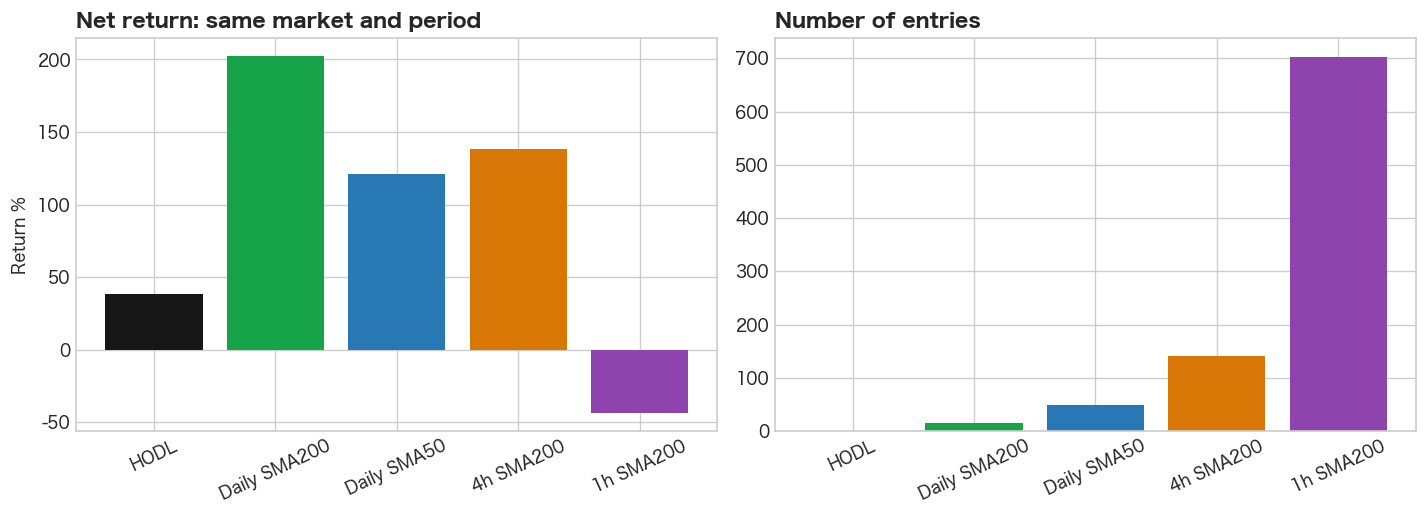

,rule,start,end,return_pct,maxdd_pct,entries
0,HODL,2022-01-01 00:00:00+00:00,2026-07-29 14:00:00+00:00,38.64,-67.38,1
1,Daily SMA200,2022-01-01 00:00:00+00:00,2026-07-29 14:00:00+00:00,202.46,-31.39,16
2,Daily SMA50,2022-01-01 00:00:00+00:00,2026-07-29 14:00:00+00:00,120.93,-50.57,49
3,4h SMA200,2022-01-01 00:00:00+00:00,2026-07-29 14:00:00+00:00,138.22,-33.00,141
4,1h SMA200,2022-01-01 00:00:00+00:00,2026-07-29 14:00:00+00:00,-43.91,-64.71,703


In [2]:
hourly_close = hourly["close"].copy()
hourly_close.index = hourly_close.index + pd.Timedelta(hours=1)

four_hour_close = hourly["close"].resample("4h", label="left", closed="left").last().dropna()
four_hour_close.index = four_hour_close.index + pd.Timedelta(hours=4)

daily_close = boundary_closes(hourly, "UTC")
timeframe_signals = {
    "Daily SMA200": make_signal(daily_close, 200)["signal"],
    "Daily SMA50": make_signal(daily_close, 50)["signal"],
    "4h SMA200": make_signal(four_hour_close, 200)["signal"],
    "1h SMA200": make_signal(hourly_close, 200)["signal"],
}
timeframe_frames = {name: strategy_from_signal(signal, 1) for name, signal in timeframe_signals.items()}
timeframe_frames["HODL"] = hodl_frame()
order = ["HODL", "Daily SMA200", "Daily SMA50", "4h SMA200", "1h SMA200"]
tf = pd.DataFrame([metric_row(name, timeframe_frames[name]) for name in order])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
axes[0].bar(tf["rule"], tf["total_return"] * 100, color=["#171717", "#16a34a", "#2878b5", "#d97706", "#8e44ad"])
axes[0].set_title("Net return: same market and period", loc="left", weight="bold")
axes[0].set_ylabel("Return %")
axes[1].bar(tf["rule"], tf["entries"], color=["#171717", "#16a34a", "#2878b5", "#d97706", "#8e44ad"])
axes[1].set_title("Number of entries", loc="left", weight="bold")
for ax in axes:
    ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

tf_display = tf[["rule", "start", "end", "total_return", "max_drawdown", "entries"]].copy()
tf_display["return_pct"] = tf_display["total_return"] * 100
tf_display["maxdd_pct"] = tf_display["max_drawdown"] * 100
display(tf_display[["rule", "start", "end", "return_pct", "maxdd_pct", "entries"]].round(2))

結果:

- 同じ現物市場・同じ2022年開始・同じ1時間遅延で比較
- 短期足ほど判定が頻繁に切り替わり、コストの影響が大きい
- 以降は日足を市場環境フィルターとして検証

## 2. 日足の何日線を見るか

**仮説**  
中長期帯に安定した範囲がある（短すぎるMAはダマシが多く長すぎるMAは反応が遅いため）。

**チャートの見方**

- 緑背景: BTCをロング
- 赤背景: BTCを保有せず待機
- 黒線: BTC価格
- 色付きの線: 移動平均線

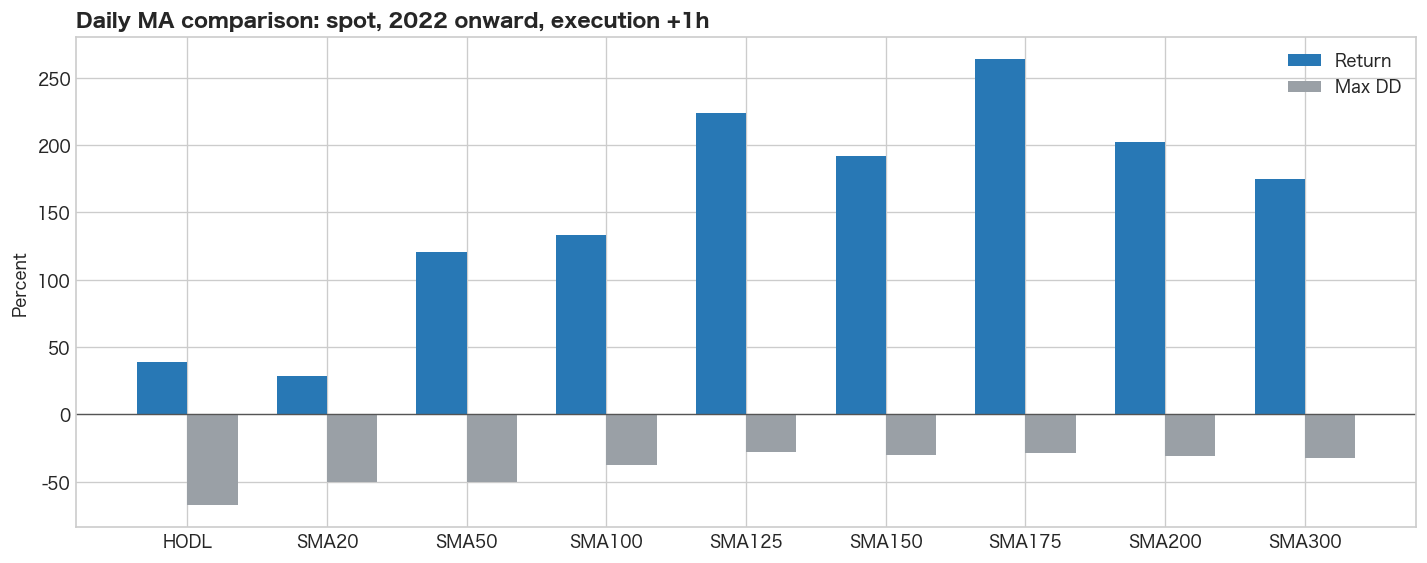

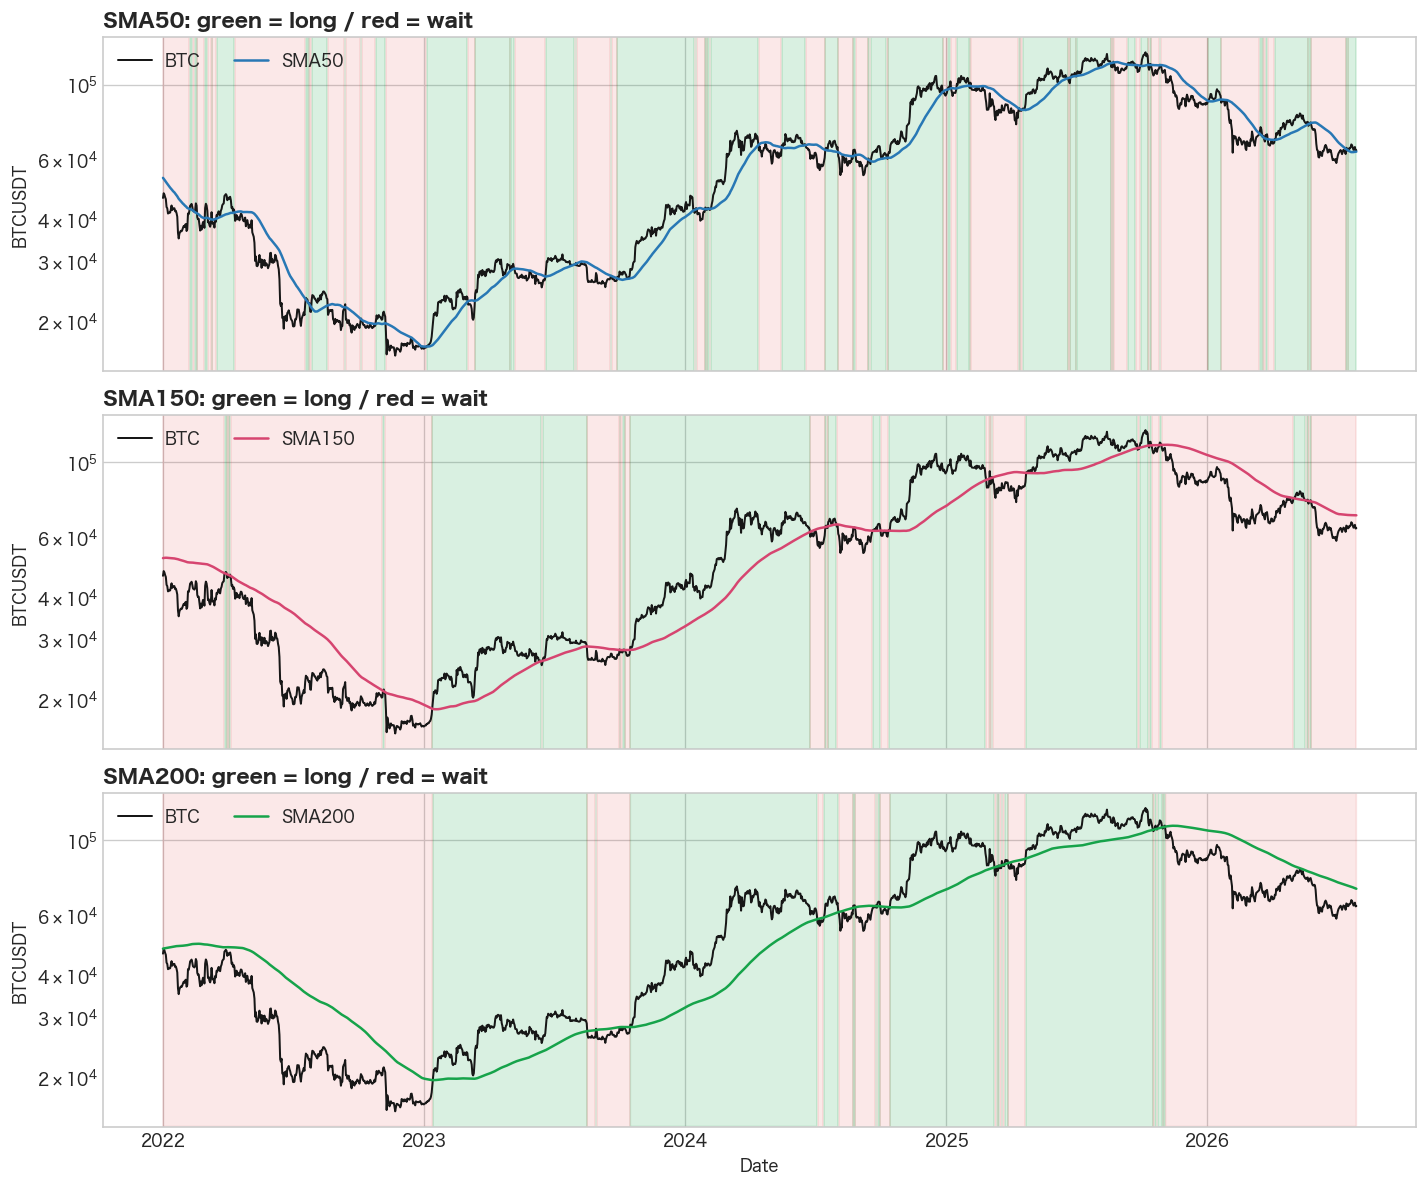

,rule,return_pct,maxdd_pct,sharpe,exposure_pct,entries
0,HODL,38.64,-67.38,0.39,100.00,1
1,SMA20,28.72,-50.05,0.33,49.98,94
2,SMA50,120.93,-50.57,0.70,50.02,49
3,SMA100,133.34,-37.57,0.74,49.20,31
4,SMA125,224.12,-27.71,0.97,50.34,21
5,SMA150,191.78,-30.08,0.89,50.10,21
6,SMA175,263.79,-29.00,1.03,50.22,10
7,SMA200,202.46,-31.39,0.90,51.12,16
8,SMA300,174.82,-32.51,0.79,60.28,9


,rule,period,return_pct,maxdd_pct,sharpe,entries
0,SMA125,2022-2023,73.83,-23.62,1.11,7
1,SMA125,2024 onward,86.36,-27.71,0.88,15
2,SMA150,2022-2023,80.47,-21.74,1.18,8
3,SMA150,2024 onward,61.60,-30.08,0.71,14
4,SMA175,2022-2023,91.08,-21.74,1.30,2
5,SMA175,2024 onward,90.29,-29.00,0.88,9
6,SMA200,2022-2023,88.12,-21.74,1.27,3
7,SMA200,2024 onward,60.70,-31.39,0.69,14


In [3]:
WINDOWS = [20, 50, 100, 125, 150, 175, 200, 300]
daily_frames = {f"SMA{window}": regime_frame("UTC", window, 1) for window in WINDOWS}
daily_frames["HODL"] = hodl_frame()
order = ["HODL", *[f"SMA{window}" for window in WINDOWS]]
daily = pd.DataFrame([metric_row(name, daily_frames[name]) for name in order])

fig, ax = plt.subplots(figsize=(12, 4.8))
x = np.arange(len(daily))
width = 0.36
ax.bar(x - width/2, daily["total_return"] * 100, width, color="#2878b5", label="Return")
ax.bar(x + width/2, daily["max_drawdown"] * 100, width, color="#9aa0a6", label="Max DD")
ax.axhline(0, color="#555", lw=0.8)
ax.set_xticks(x, daily["rule"])
ax.set_title("Daily MA comparison: spot, 2022 onward, execution +1h", loc="left", weight="bold")
ax.set_ylabel("Percent")
ax.legend()
plt.tight_layout()
plt.show()

daily_signal = {window: make_signal(daily_close, window) for window in [50, 150, 200]}
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for ax, window in zip(axes, [50, 150, 200]):
    signal_frame = daily_signal[window].loc[ANALYSIS_START:]
    is_long = signal_frame["signal"].eq(1)
    is_wait = signal_frame["signal"].eq(0)
    ax.fill_between(signal_frame.index, 0, 1, where=is_long, transform=ax.get_xaxis_transform(), step="post", color="#16a34a", alpha=0.16)
    ax.fill_between(signal_frame.index, 0, 1, where=is_wait, transform=ax.get_xaxis_transform(), step="post", color="#dc2626", alpha=0.10)
    ax.plot(signal_frame.index, signal_frame["close"], color="#171717", lw=1.2, label="BTC")
    ax.plot(signal_frame.index, signal_frame["ma"], color=COLORS[f"SMA{window}"], lw=1.5, label=f"SMA{window}")
    ax.set_yscale("log")
    ax.set_ylabel("BTCUSDT")
    ax.set_title(f"SMA{window}: green = long / red = wait", loc="left", weight="bold")
    ax.legend(loc="upper left", ncol=2)
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

split_rows = []
for window in [125, 150, 175, 200]:
    name = f"SMA{window}"
    for period, start, end in [
        ("2022-2023", "2022-01-01", "2023-12-31 23:00"),
        ("2024 onward", "2024-01-01", None),
    ]:
        row = period_metric(name, daily_frames[name], start, end)
        split_rows.append({"rule": name, "period": period, **row})
split = pd.DataFrame(split_rows)
daily_display = daily[["rule", "total_return", "max_drawdown", "sharpe", "exposure", "entries"]].copy()
daily_display["return_pct"] = daily_display["total_return"] * 100
daily_display["maxdd_pct"] = daily_display["max_drawdown"] * 100
daily_display["exposure_pct"] = daily_display["exposure"] * 100
display(daily_display[["rule", "return_pct", "maxdd_pct", "sharpe", "exposure_pct", "entries"]].round(2))

split_display = split[["rule", "period", "total_return", "max_drawdown", "sharpe", "entries"]].copy()
split_display["return_pct"] = split_display["total_return"] * 100
split_display["maxdd_pct"] = split_display["max_drawdown"] * 100
display(split_display[["rule", "period", "return_pct", "maxdd_pct", "sharpe", "entries"]].round(2))

結果:

- 125〜200日付近に比較的良い範囲がある
- 150日と200日の成績差は小さく、150日だけが特別に機能しているとはいえない
- 175日は全期間では最良でも、結果を見て採用すると過剰最適化になる
- 期間を分けても順位は変わるため、最良の1本ではなく安定帯として扱う

## 3. 研究代表としてSMA150を掘り下げる

SMA150を選択した理由

- 125〜200日の安定帯に含まれる
- 全期間のエントリーが21回あり、SMA175の10回より観測数が多い
- 当初から検証していた代表候補である

長期MAによるロング環境判定の性質を確認する代表値として使用します。

```text
日足終値 > SMA150  → Signal ON  → 1時間後にBTCロング
日足終値 <= SMA150 → Signal OFF → 1時間後にBTCを売却して待機
```

* 価格チャートの三角は約定ではなく、日足確定時のSignal切り替えを示します。
* なぜ1時間後か：日足終値を確認後にすぐ終値で約定することは実際には難しい都合のよい約定になるため

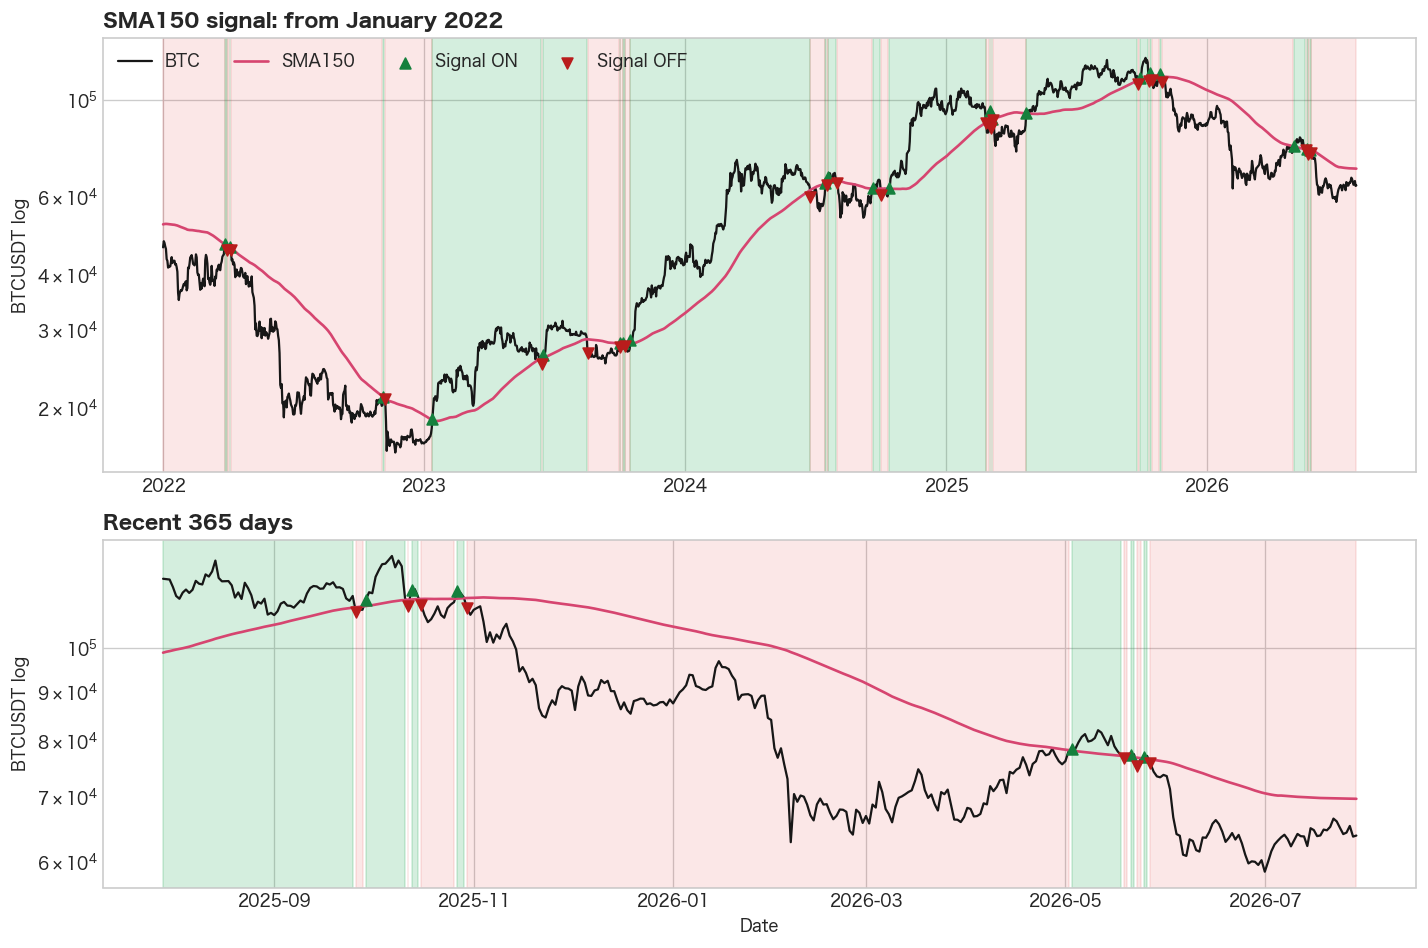

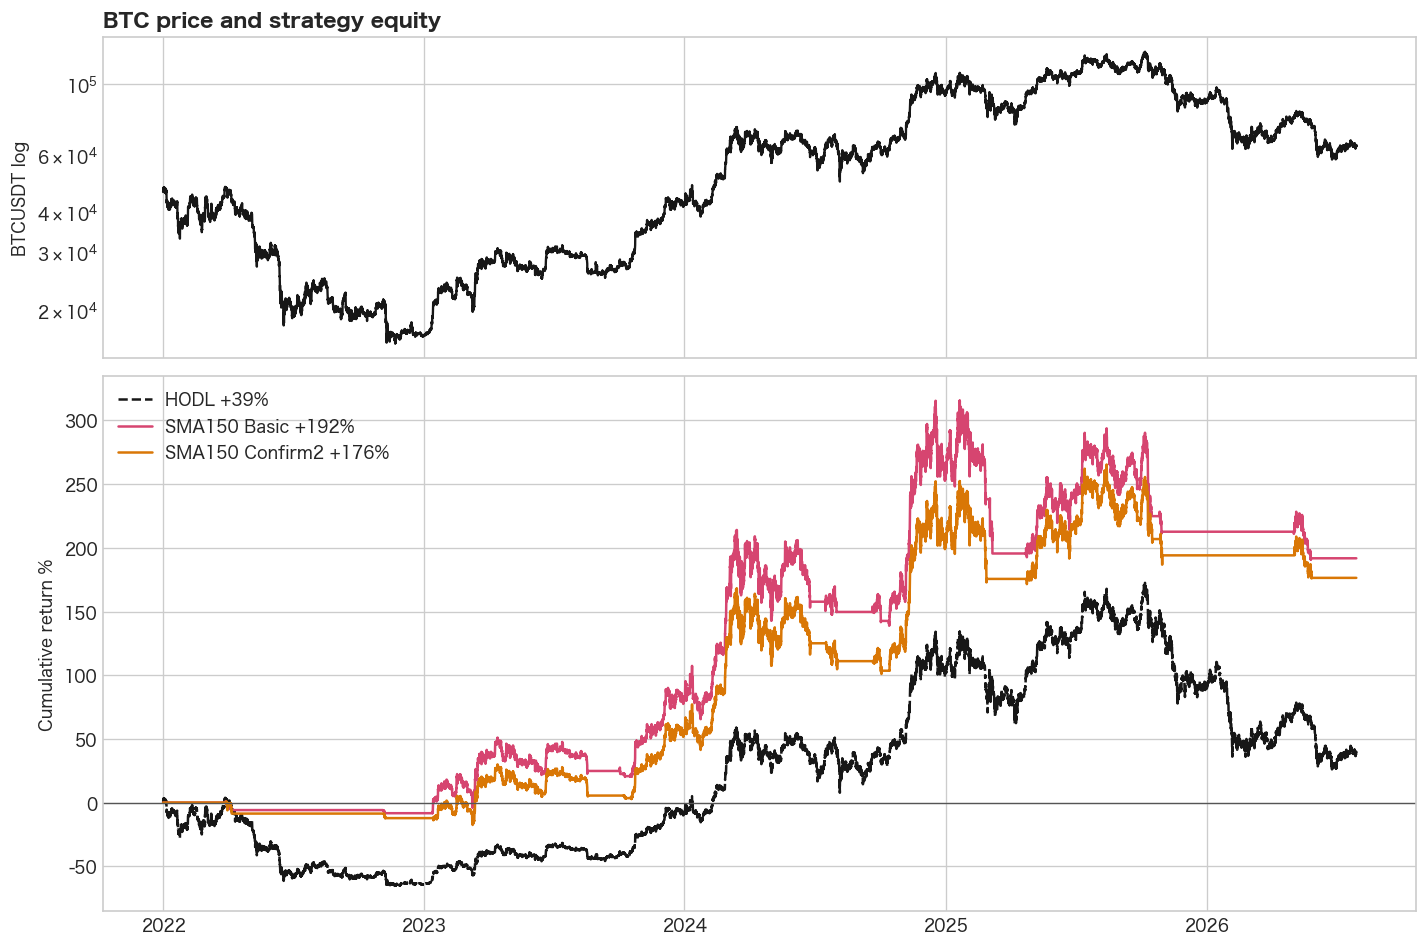

,rule,return_pct,maxdd_pct,exposure_pct,entries
0,HODL,38.64,-67.38,100.00,1
1,SMA150 Basic,191.78,-30.08,50.10,21
2,SMA150 Confirm2,176.41,-25.08,49.98,17


In [4]:
signal_basic = make_signal(daily_close, 150, rule="Basic")
signal_confirm2 = make_signal(daily_close, 150, rule="Confirm2")
strategy_frames = {
    "HODL": hodl_frame(),
    "SMA150 Basic": strategy_from_signal(signal_basic["signal"], 1),
    "SMA150 Confirm2": strategy_from_signal(signal_confirm2["signal"], 1),
}

view = signal_basic.loc[ANALYSIS_START:].copy()
changes = view["signal"].diff()
signal_on = changes.eq(1)
signal_off = changes.eq(-1)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={"height_ratios": [1.25, 1]})
for ax, chart_view, title in [
    (axes[0], view, "SMA150 signal: from January 2022"),
    (axes[1], view.loc[view.index >= view.index.max() - pd.Timedelta(days=365)], "Recent 365 days"),
]:
    is_long = chart_view["signal"].eq(1)
    is_wait = chart_view["signal"].eq(0)
    on = signal_on.reindex(chart_view.index, fill_value=False)
    off = signal_off.reindex(chart_view.index, fill_value=False)
    ax.fill_between(chart_view.index, 0, 1, where=is_long, transform=ax.get_xaxis_transform(), step="post", color="#16a34a", alpha=0.18)
    ax.fill_between(chart_view.index, 0, 1, where=is_wait, transform=ax.get_xaxis_transform(), step="post", color="#dc2626", alpha=0.11)
    ax.plot(chart_view.index, chart_view["close"], color="#171717", lw=1.35, label="BTC")
    ax.plot(chart_view.index, chart_view["ma"], color=COLORS["SMA150"], lw=1.6, label="SMA150")
    ax.scatter(chart_view.index[on], chart_view.loc[on, "close"], marker="^", s=42, color="#15803d", label="Signal ON", zorder=4)
    ax.scatter(chart_view.index[off], chart_view.loc[off, "close"], marker="v", s=42, color="#b91c1c", label="Signal OFF", zorder=4)
    ax.set_yscale("log")
    ax.set_ylabel("BTCUSDT log")
    ax.set_title(title, loc="left", weight="bold")
axes[0].legend(loc="upper left", ncol=4)
axes[1].set_xlabel("Date")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": [1.2, 2]})
price_view = hourly.loc[ANALYSIS_START:, "open"]
axes[0].plot(price_view.index, price_view, color="#171717", lw=1.4)
axes[0].set_yscale("log")
axes[0].set_ylabel("BTCUSDT log")
axes[0].set_title("BTC price and strategy equity", loc="left", weight="bold")
for name, frame in strategy_frames.items():
    curve = (frame["net_equity"] - 1) * 100
    axes[1].plot(curve.index, curve, label=f"{name} {curve.iloc[-1]:+.0f}%", color=COLORS[name], ls="--" if name == "HODL" else "-")
axes[1].axhline(0, color="#555", lw=0.8)
axes[1].set_ylabel("Cumulative return %")
axes[1].legend()
plt.tight_layout()
plt.show()

full = pd.DataFrame([metric_row(name, frame) for name, frame in strategy_frames.items()])
full_display = full[["rule", "total_return", "max_drawdown", "exposure", "entries"]].copy()
full_display["return_pct"] = full_display["total_return"] * 100
full_display["maxdd_pct"] = full_display["max_drawdown"] * 100
full_display["exposure_pct"] = full_display["exposure"] * 100
display(full_display[["rule", "return_pct", "maxdd_pct", "exposure_pct", "entries"]].round(2))

| ルール | 判定方法 |
|---|---|
| SMA150 Basic | 1日でもSMA150を上回ればロング。下回れば待機 |
| SMA150 Confirm2 | 2日連続で上回ればロング。2日連続で下回れば待機 |

結果:

- SMA150 Basicは長期下落時のBTC保有を減らし、HODLよりMaxDDを抑えた
- 2日確認は売買回数とMaxDDを抑える防御型候補
- 表示値は日足確定から1時間後に約定し、片道5bpsを控除した結果
- Signalマーカーと実際の約定時刻には1時間の差がある

## 4. 日足区切りと約定時刻を変える

UTCという時間軸の区切りを選んだから良い成績がでたのではないか、という疑念を払拭

BTCは24時間取引されるため、日足の区切り方によって終値とSignalが変わります。
また、日足確定後すぐに売買できる前提だけで成績がよい可能性もあります。

そこで、

- UTC 00:00
- New York 16:00
- 約定遅延 0時間・1時間・4時間

を比較し、日足区切りや約定時刻を変えても結果が残るか確認します。

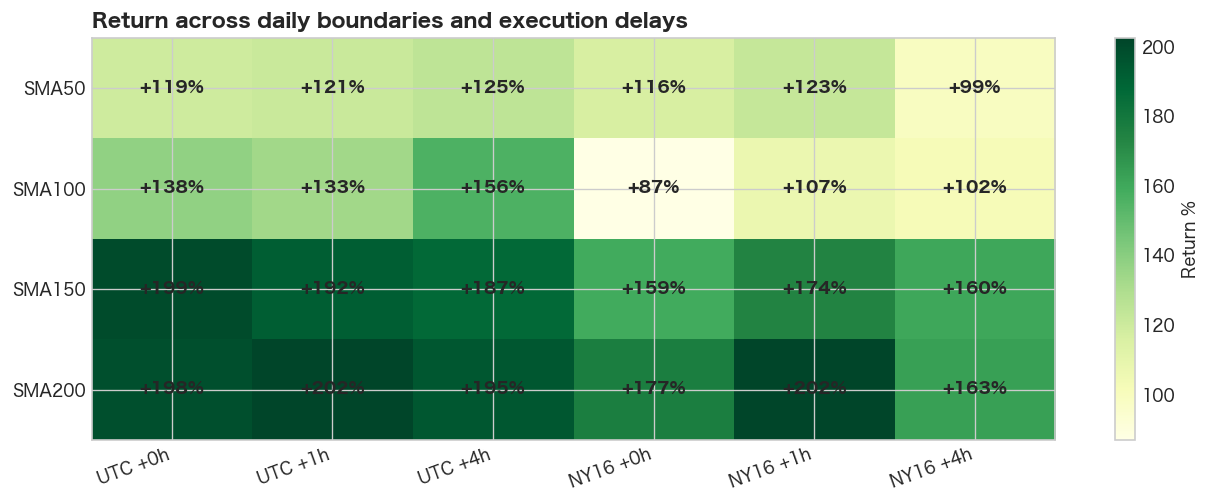

,boundary,delay_hours,window,return_pct,maxdd_pct,entries
0,UTC,0,50,119.37,-52.10,49
1,UTC,0,100,137.62,-36.38,31
2,UTC,0,150,199.35,-27.07,21
3,UTC,0,200,197.56,-33.80,16
4,UTC,1,50,120.93,-50.57,49
5,UTC,1,100,133.34,-37.57,31
6,UTC,1,150,191.78,-30.08,21
7,UTC,1,200,202.46,-31.39,16
8,UTC,4,50,124.83,-50.16,49
9,UTC,4,100,155.57,-33.42,31


In [5]:
TIMING_WINDOWS = [50, 100, 150, 200]
BOUNDARIES = ["UTC", "NY16"]
DELAYS = [0, 1, 4]
timing_rows = []
for boundary in BOUNDARIES:
    for delay in DELAYS:
        for window in TIMING_WINDOWS:
            frame = regime_frame(boundary, window, delay)
            row = metric_row(f"SMA{window}", frame)
            timing_rows.append({
                "boundary": boundary,
                "delay_hours": delay,
                "variant": f"{boundary} +{delay}h",
                "window": window,
                **row,
            })
timing = pd.DataFrame(timing_rows)
variants = [f"{boundary} +{delay}h" for boundary in BOUNDARIES for delay in DELAYS]
heat = timing.pivot(index="window", columns="variant", values="total_return").loc[TIMING_WINDOWS, variants] * 100

fig, ax = plt.subplots(figsize=(11, 4.3))
im = ax.imshow(heat, cmap="YlGn", aspect="auto")
ax.set_xticks(range(len(heat.columns)), heat.columns, rotation=20, ha="right")
ax.set_yticks(range(len(heat.index)), [f"SMA{x}" for x in heat.index])
for r in range(heat.shape[0]):
    for c in range(heat.shape[1]):
        ax.text(c, r, f"{heat.iloc[r,c]:+.0f}%", ha="center", va="center", weight="bold")
ax.set_title("Return across daily boundaries and execution delays", loc="left", weight="bold")
fig.colorbar(im, ax=ax, label="Return %")
plt.tight_layout()
plt.show()

timing_display = timing[["boundary", "delay_hours", "window", "total_return", "max_drawdown", "entries"]].copy()
timing_display["return_pct"] = timing_display["total_return"] * 100
timing_display["maxdd_pct"] = timing_display["max_drawdown"] * 100
display(timing_display[["boundary", "delay_hours", "window", "return_pct", "maxdd_pct", "entries"]].round(2))

結果:

- SMA150とSMA200の両方で、UTC・New York、0・1・4時間遅延でも利益が残った
- 日足区切りや即時約定だけに依存する結果ではない
- 150日と200日の優劣は条件によって変わり、長期MA帯としての頑健性が重要

## 5. SMA vs EMA

**仮説**  
EMAでも利益が残ればSMA固有ではなく長期トレンド判定自体に意味がある。

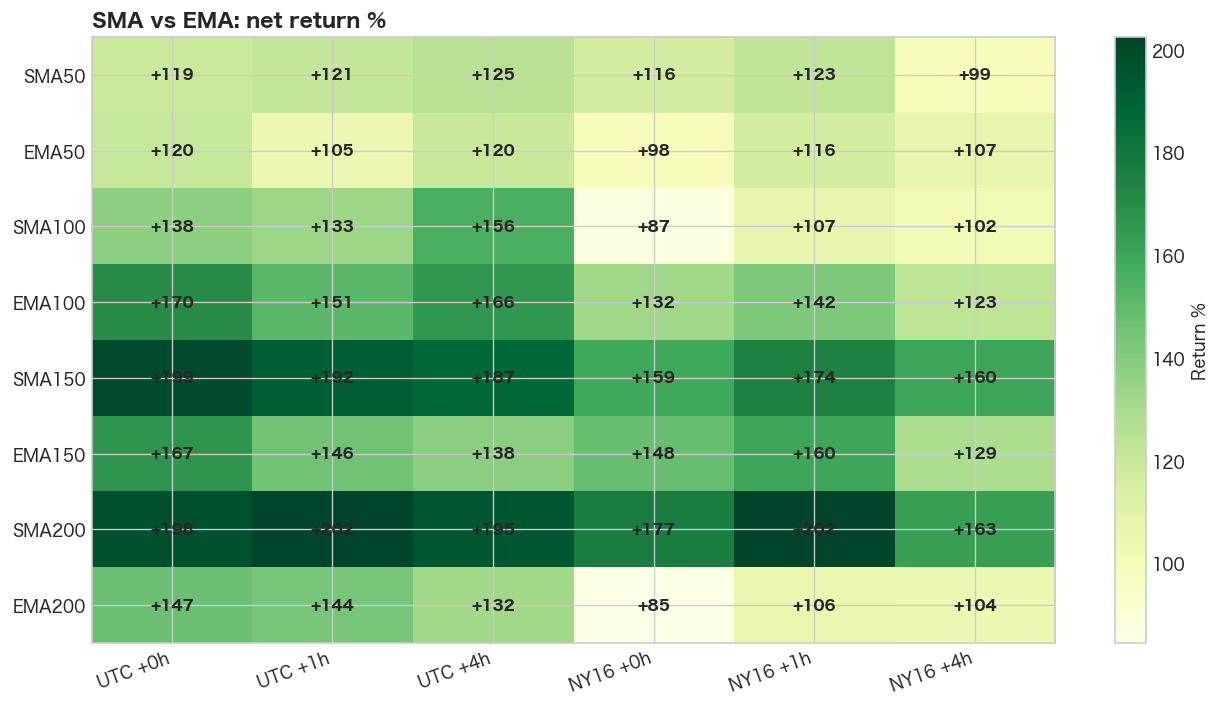

In [6]:
METHOD_WINDOWS = [50, 100, 150, 200]
method_rows = []
for kind in ["SMA", "EMA"]:
    for window in METHOD_WINDOWS:
        for boundary in BOUNDARIES:
            for delay in DELAYS:
                frame = regime_frame(boundary, window, delay, kind=kind)
                row = metric_row(f"{kind}{window}", frame)
                method_rows.append({
                    "method": f"{kind}{window}",
                    "variant": f"{boundary} +{delay}h",
                    "total_return": row["total_return"],
                    "max_drawdown": row["max_drawdown"],
                })
se = pd.DataFrame(method_rows)
method_order = [f"{kind}{window}" for window in METHOD_WINDOWS for kind in ["SMA", "EMA"]]
variants = [f"{boundary} +{delay}h" for boundary in BOUNDARIES for delay in DELAYS]
heat = se.pivot(index="method", columns="variant", values="total_return").loc[method_order, variants] * 100

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(heat, cmap="YlGn", aspect="auto")
ax.set_xticks(range(len(heat.columns)), heat.columns, rotation=20, ha="right")
ax.set_yticks(range(len(heat.index)), heat.index)
for r in range(heat.shape[0]):
    for c in range(heat.shape[1]):
        ax.text(c, r, f"{heat.iloc[r,c]:+.0f}", ha="center", va="center", fontsize=9, weight="bold")
ax.set_title("SMA vs EMA: net return %", loc="left", weight="bold")
fig.colorbar(im, ax=ax, label="Return %")
plt.tight_layout()
plt.show()

結果:

- SMAとEMAの両方で中長期トレンド判定の効果が残った
- SMA150だけの特殊な結果ではない
- SMA200も含め、単一の日数より長期MA帯として扱う

## 6. SMA150 : ダマシを減らす

**仮説**  
MA付近の往復売買を減らせばリターンを維持しながらDDと売買回数を減らせる。

```text
Basic:   終値がSMAより上ならロング
Band1%:  1%上でロング、1%下で売却
Confirm2: 2日連続で上ならロング、2日連続で下なら売却
```

,min_return_pct,max_return_pct,worst_dd_pct,entries
rule,,,,
Basic,159.14,199.35,-34.21,23.5
Band1%,149.14,180.17,-30.85,13.5
Confirm2,152.13,198.26,-27.88,15.5


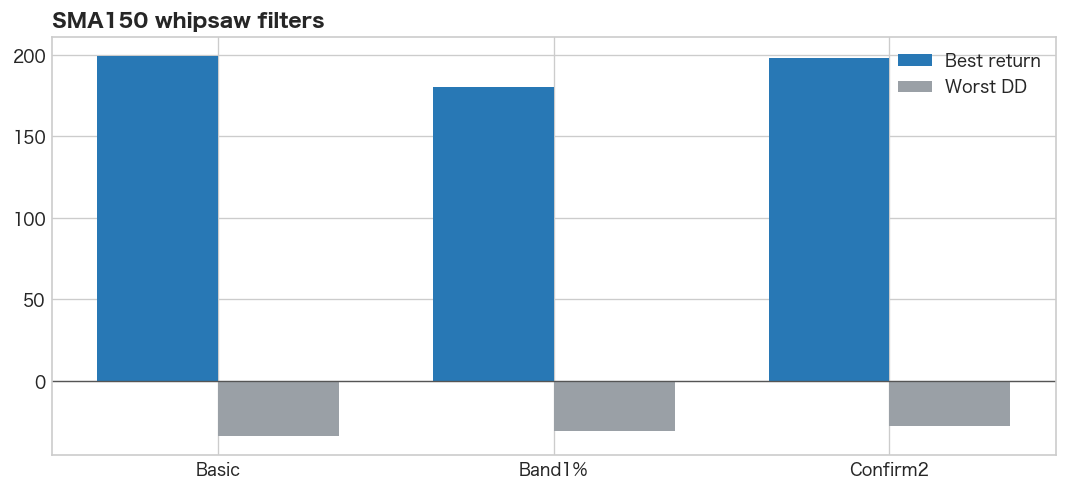

In [7]:
whip = part("whipsaw_metrics")
focus = whip[whip["window"] == 150].groupby("rule").agg(
    min_return=("total_return", "min"),
    max_return=("total_return", "max"),
    worst_dd=("max_drawdown", "min"),
    entries=("entries", "mean"),
).loc[["Basic","Band1%","Confirm2"]]
focus[["min_return","max_return","worst_dd"]] *= 100
focus_display = focus.rename(columns={
    "min_return": "min_return_pct",
    "max_return": "max_return_pct",
    "worst_dd": "worst_dd_pct",
})
display(focus_display.round(2))

fig, ax = plt.subplots(figsize=(9, 4.2))
x = np.arange(len(focus))
ax.bar(x - 0.18, focus["max_return"], 0.36, color="#2878b5", label="Best return")
ax.bar(x + 0.18, focus["worst_dd"], 0.36, color="#9aa0a6", label="Worst DD")
ax.set_xticks(x, focus.index)
ax.axhline(0, color="#555", lw=0.8)
ax.set_title("SMA150 whipsaw filters", loc="left", weight="bold")
ax.legend()
plt.tight_layout()
plt.show()

結果:

- 1%バンドはリターン低下
- 2日確認はリターンをほぼ維持
- MaxDDと売買回数は改善


大きく差はない。

## 7. 3本のMAを判定に使う

**仮説**  
SMA50・100・150のうち2本以上を上回ったときだけロングすれば単一MAよりも利益が出る。

,boundary,compared_with,exact_agreement_pct,different_days,n_days
3864,UTC,SMA50,83.00,284.0,1671.0
3865,UTC,SMA100,98.80,20.0,1671.0
3866,UTC,SMA150,93.48,109.0,1671.0
3867,NY16,SMA50,82.69,289.0,1670.0
3868,NY16,SMA100,98.98,17.0,1670.0
3869,NY16,SMA150,93.47,109.0,1670.0


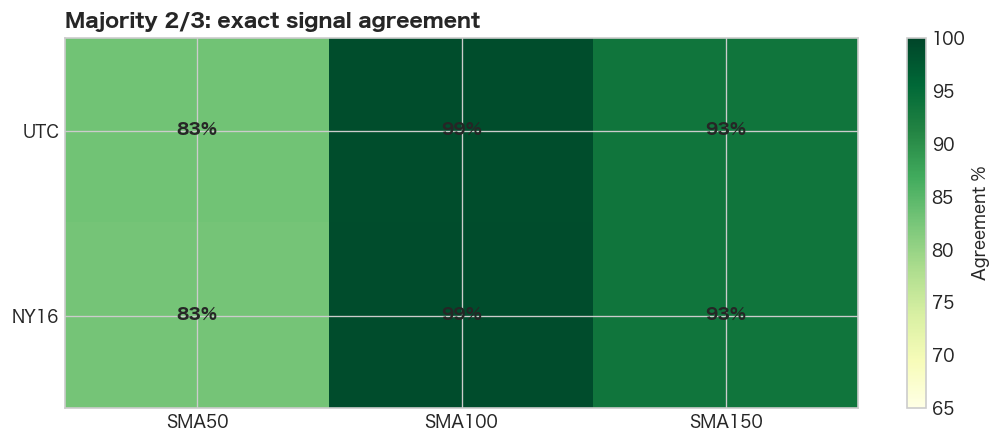

In [8]:
overlap = part("majority_overlap")
overlap["exact_agreement_pct"] = overlap["exact_agreement"] * 100
display(overlap[["boundary","compared_with","exact_agreement_pct","different_days","n_days"]].round(2))

fig, ax = plt.subplots(figsize=(9, 3.8))
view = overlap.pivot(index="boundary", columns="compared_with", values="exact_agreement_pct").loc[["UTC","NY16"],["SMA50","SMA100","SMA150"]]
im = ax.imshow(view, cmap="YlGn", vmin=65, vmax=100, aspect="auto")
ax.set_xticks(range(3), view.columns)
ax.set_yticks(range(2), view.index)
for r in range(2):
    for c in range(3):
        ax.text(c, r, f"{view.iloc[r,c]:.0f}%", ha="center", va="center", weight="bold")
ax.set_title("Majority 2/3: exact signal agreement", loc="left", weight="bold")
fig.colorbar(im, ax=ax, label="Agreement %")
plt.tight_layout()
plt.show()

結果:

- 2/3合議とSMA100の一致率は約99%
- 多数決に見えるが、実質的にSMA100
- 情報が増えないため不採用

## 8. 長期下落の回避

**仮説**  
SMA150の優位性は長期下落の回避からきている。


直近高値から15%以上下落した7局面を確認します。

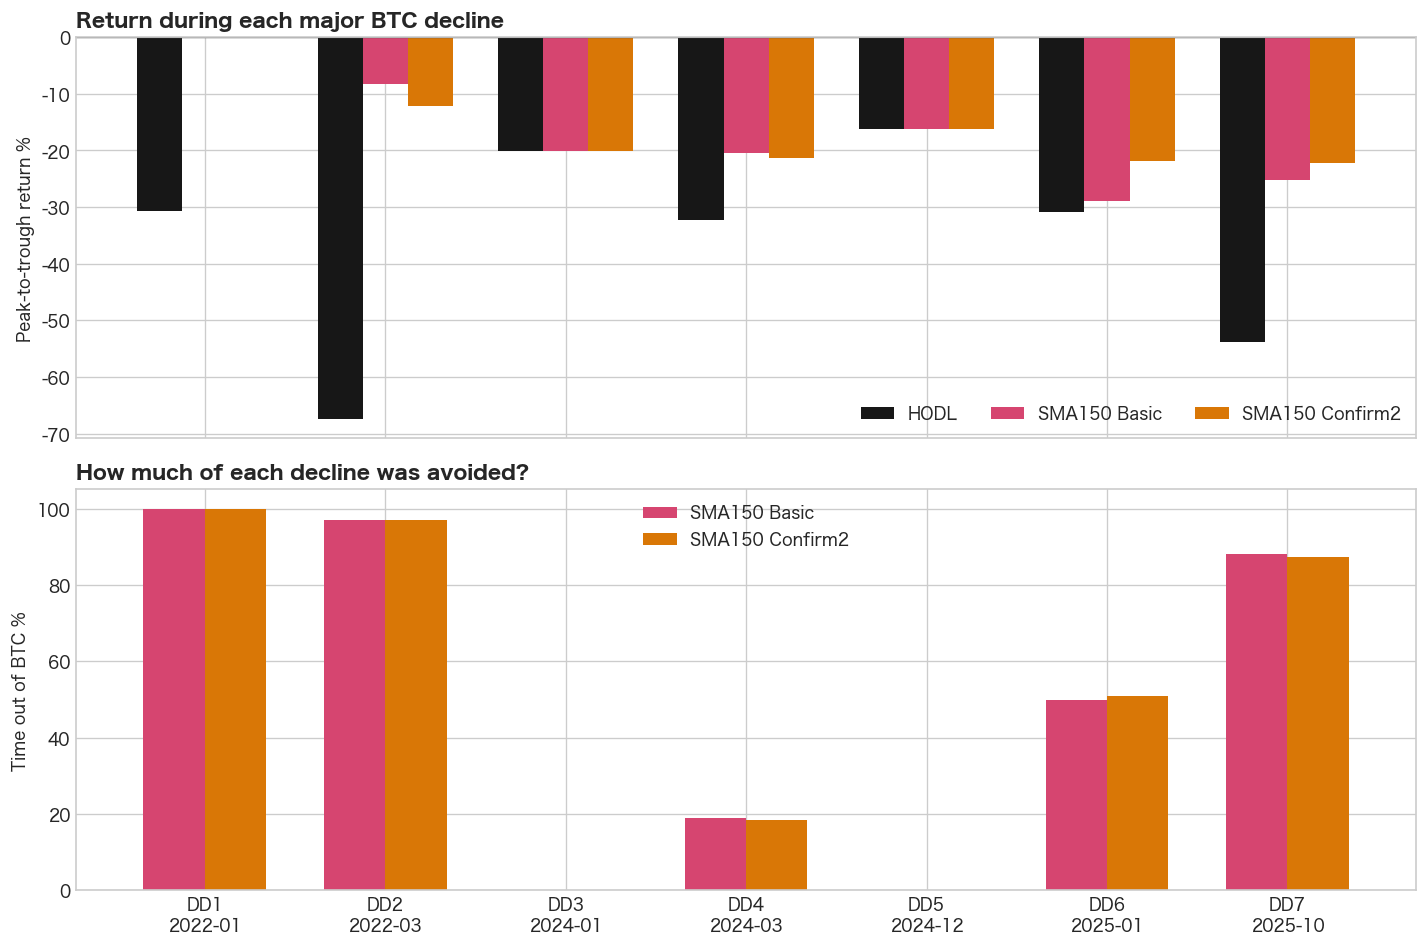

In [9]:
events = part("drawdown_events")
detail = part("drawdown_detail")
event_order = events["event_id"].tolist()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
x = np.arange(len(event_order))
width = 0.25
for i, strategy in enumerate(["HODL","SMA150 Basic","SMA150 Confirm2"]):
    values = detail[detail["strategy"] == strategy].set_index("event_id").loc[event_order, "decline_return"] * 100
    axes[0].bar(x + (i-1)*width, values, width, label=strategy, color=COLORS[strategy])
axes[0].axhline(0, color="#555", lw=0.8)
axes[0].set_ylabel("Peak-to-trough return %")
axes[0].set_title("Return during each major BTC decline", loc="left", weight="bold")
axes[0].legend(ncol=3)

for i, strategy in enumerate(["SMA150 Basic","SMA150 Confirm2"]):
    values = detail[detail["strategy"] == strategy].set_index("event_id").loc[event_order, "decline_out_share"] * 100
    axes[1].bar(x + (i-0.5)*0.34, values, 0.34, label=strategy, color=COLORS[strategy])
axes[1].set_xticks(x, [f"{row.event_id}\n{str(row.peak_time)[:7]}" for row in events.itertuples()])
axes[1].set_ylabel("Time out of BTC %")
axes[1].set_title("How much of each decline was avoided?", loc="left", weight="bold")
axes[1].legend()
plt.tight_layout()
plt.show()

結果:

- 2022年の長期下落`-67%`を大きく回避
- 2025年10月以降の下落`-54%`も約88%の期間でBTCを持たなかった
- 2024年1月など短期急落は回避できなかった
- 通常期間ではHODLに負け、長期下落期間で上回った

## 9. 現時点の研究仕様

### 代表仕様: SMA150

```text
UTC日足終値 > SMA150  : Signal ON  → 1時間後にBTCロング
UTC日足終値 <= SMA150 : Signal OFF → 1時間後にBTCを売却して待機
```

### 防御版

```text
2日連続で終値 > SMA150  : Signal ON  → 1時間後にBTCロング
2日連続で終値 <= SMA150 : Signal OFF → 1時間後にBTCを売却して待機
```

SMA150は研究上の代表値です。SMA200も同じ長期MA帯の有力候補として残します。

## 10. ここまでの結論

```text
移動平均線は翌日の価格を当てるものではない
↓
長期下落でBTCを持たないための環境フィルター
↓
2022年以降では125〜200日付近に比較的良い範囲
↓
150日と200日の差は小さく、最良の1本は未確定
```

**一言でいうと**  
長期MA帯は長期下落へのエクスポージャーを減らしたが、SMA150を最適値と断定できる段階ではない。

## 11. まだ分からないこと

- 125〜200日の優位性が将来も残るか
- HODLとの差が統計的に有意か
- 2022年開始という起点への依存がどの程度あるか
- 2017年以降など複数サイクルでも同じ傾向になるか
- 急落前に退避できるか

複数条件を比較した後の結果なので、SMA150・SMA200とも研究候補です。

## 12. 検証から生まれた次の仮説

ここまでの出発点は「BTCの200日線はロング環境判定に使えるか」でした。
そこで、米国の現物BTC ETF開始後に、200日線付近の市場反応が150日線・175日線より強くなったかを探索します。


In [10]:
ETF_DAILY_PATH = RESEARCH_ROOT / "data" / "binance_spot_BTCUSDT_1d_2017_latest.parquet"
if not ETF_DAILY_PATH.exists():
    raise FileNotFoundError(f"日足データが見つかりません: {ETF_DAILY_PATH}")

etf_daily_raw = pd.read_parquet(ETF_DAILY_PATH)
etf_daily, etf_data_report = check_and_clean(
    etf_daily_raw[["open", "high", "low", "close", "volume"]],
    source_name="binance_spot_BTCUSDT_1d_ETF_MA_attention_study",
)
print(etf_data_report.summary())
if etf_data_report.worst_level == "CRITICAL":
    raise RuntimeError("データ品質がCRITICALのためETF前後検証を中断します。")

print("ETF study data:", ETF_DAILY_PATH.name)
print("Range:", etf_daily.index.min(), "to", etf_daily.index.max())

DataChecker レポート  [binance_spot_BTCUSDT_1d_ETF_MA_attention_study]
元データ行数:     3,268
クレンジング後:   3,268
総合判定:         OK
------------------------------------------------------------
✅ [OK      ] 重複行
           重複なし
✅ [OK      ] 時系列順
           昇順で整列済み
✅ [OK      ] 欠損タイムスタンプ
           欠損なし（推定時間足: 1 days 00:00:00）
✅ [OK      ] NaN値
           価格列に NaN なし
✅ [OK      ] 価格妥当性
           価格 > 0.0 を確認
✅ [OK      ] OHLC整合性
           high >= low を確認
✅ [OK      ] 急変動チェック
           ±50% 超の変動なし
✅ [OK      ] 出来高ゼロ連続
           出来高ゼロ連続の最大: 0 本（閾値: 3）
ETF study data: binance_spot_BTCUSDT_1d_2017_latest.parquet
Range: 2017-08-17 00:00:00+00:00 to 2026-07-28 00:00:00+00:00


## 13. ETF前後の検証設計

米SECは2024年1月10日に現物BTC ETPの上場・取引を承認し、商品は1月11日に取引を開始しました。

- [SEC: Statement on the Approval of Spot Bitcoin Exchange-Traded Products](https://www.sec.gov/newsroom/speeches-statements/gensler-statement-spot-bitcoin-011023)
- [SEC提出資料: 2024年1月11日の取引開始](https://www.sec.gov/Archives/edgar/data/1050446/000119312525230977/d49048d8k.htm)

**期間**

| 区分 | 定義 |
|---|---|
| ETF前 | 2024年1月10日まで |
| 移行期間 | 2024年1月11日〜2024年6月30日 |
| ETF定着後 | 2024年7月1日以降 |

**評価指標**

| 指標 | この検証での定義 |
|---|---|
| 接近時出来高 | MAの±1%圏へ外側から入った日のドル出来高 ÷ 直前30日中央値 |
| クロス後リターン | 上抜けは通常の将来リターン、下抜けは符号を反転した1・7・30日リターン |
| ダマシ率 | クロス後10・20日以内に再び反対側へ戻った割合 |

主対象はSMA150・175・200です。SMA160・190・225も偽薬条件として計算し、「200日だけの変化」か「長期MA帯全体の変化」かを区別します。

In [11]:
ETF_TRADING_START = pd.Timestamp("2024-01-11", tz="UTC")
ETF_STABLE_START = pd.Timestamp("2024-07-01", tz="UTC")
MAIN_WINDOWS = [150, 175, 200]
PLACEBO_WINDOWS = [160, 190, 225]
ETF_WINDOWS = sorted(MAIN_WINDOWS + PLACEBO_WINDOWS)
PROXIMITY_BAND = 0.01

close = etf_daily["close"]
dollar_volume = etf_daily["close"] * etf_daily["volume"]
relative_volume = dollar_volume / dollar_volume.rolling(30, min_periods=30).median().shift(1)

period = pd.Series("Pre ETF", index=etf_daily.index, dtype=object)
period.loc[(period.index >= ETF_TRADING_START) & (period.index < ETF_STABLE_START)] = "Transition"
period.loc[period.index >= ETF_STABLE_START] = "Post ETF"
PERIOD_ORDER = ["Pre ETF", "Transition", "Post ETF"]

event_series = {}
event_rows = []

for window in ETF_WINDOWS:
    ma = close.rolling(window, min_periods=window).mean()
    valid = ma.notna()
    state = close > ma
    near = valid & ((close / ma - 1.0).abs() <= PROXIMITY_BAND)
    approach = near & ~near.shift(1, fill_value=False)

    cross_direction = pd.Series(0, index=close.index, dtype=int)
    prior_valid = valid.shift(1, fill_value=False)
    cross_direction.loc[valid & prior_valid & state & ~state.shift(1, fill_value=False)] = 1
    cross_direction.loc[valid & prior_valid & ~state & state.shift(1, fill_value=False)] = -1
    cross_event = cross_direction.ne(0)

    values = {
        "relative_volume": relative_volume.where(approach),
        "signed_return_1d": ((close.shift(-1) / close - 1.0) * cross_direction).where(cross_event),
        "signed_return_7d": ((close.shift(-7) / close - 1.0) * cross_direction).where(cross_event),
        "signed_return_30d": ((close.shift(-30) / close - 1.0) * cross_direction).where(cross_event),
    }

    for horizon in [10, 20]:
        whipsaw = pd.Series(np.nan, index=close.index, dtype=float)
        for timestamp, direction in cross_direction[cross_event].items():
            future_state = state.loc[timestamp:].iloc[1:horizon + 1]
            if len(future_state) == horizon:
                whipsaw.loc[timestamp] = float((~future_state).any() if direction == 1 else future_state.any())
        values[f"whipsaw_{horizon}d"] = whipsaw

    for metric, series in values.items():
        event_series[(window, metric)] = series

    for period_name in PERIOD_ORDER:
        mask = period.eq(period_name)
        row = {
            "window": window,
            "period": period_name,
            "approach_events": int((mask & approach).sum()),
            "cross_events": int((mask & cross_event).sum()),
        }
        for metric, series in values.items():
            row[metric] = series.loc[mask].mean()
        event_rows.append(row)

event_summary = pd.DataFrame(event_rows)

post_end = etf_daily.index.max()
post_days = (post_end - ETF_STABLE_START).days + 1
matched_pre_end = ETF_TRADING_START - pd.Timedelta(days=1)
matched_pre_start = matched_pre_end - pd.Timedelta(days=post_days - 1)
matched_rows = []
for window in ETF_WINDOWS:
    for period_name, start, end in [
        ("Matched Pre", matched_pre_start, matched_pre_end),
        ("Post ETF", ETF_STABLE_START, post_end),
    ]:
        row = {"window": window, "period": period_name, "start": start, "end": end}
        for metric in [
            "relative_volume", "signed_return_1d", "signed_return_7d",
            "signed_return_30d", "whipsaw_10d", "whipsaw_20d",
        ]:
            row[metric] = event_series[(window, metric)].loc[start:end].mean()
            row[f"{metric}_n"] = int(event_series[(window, metric)].loc[start:end].notna().sum())
        matched_rows.append(row)
matched_summary = pd.DataFrame(matched_rows)

main_summary = event_summary[event_summary["window"].isin(MAIN_WINDOWS)].copy()
display_columns = [
    "window", "period", "approach_events", "cross_events", "relative_volume",
    "signed_return_1d", "signed_return_7d", "signed_return_30d", "whipsaw_10d", "whipsaw_20d",
]
display_main = main_summary[display_columns].copy()
for column in ["signed_return_1d", "signed_return_7d", "signed_return_30d", "whipsaw_10d", "whipsaw_20d"]:
    display_main[column] *= 100
display_main = display_main.rename(columns={
    "relative_volume": "relative_volume_ratio",
    "signed_return_1d": "signed_return_1d_pct",
    "signed_return_7d": "signed_return_7d_pct",
    "signed_return_30d": "signed_return_30d_pct",
    "whipsaw_10d": "whipsaw_10d_pct",
    "whipsaw_20d": "whipsaw_20d_pct",
})
display(display_main.round(2))
print("Matched window:", matched_pre_start.date(), "to", matched_pre_end.date(), "vs", ETF_STABLE_START.date(), "to", post_end.date())

,window,period,approach_events,cross_events,relative_volume_ratio,signed_return_1d_pct,signed_return_7d_pct,signed_return_30d_pct,whipsaw_10d_pct,whipsaw_20d_pct
0,150,Pre ETF,29,44,1.21,0.16,2.55,1.49,59.09,61.36
1,150,Transition,1,1,0.70,-2.51,-4.32,-8.43,0.00,0.00
2,150,Post ETF,24,26,1.34,0.02,1.47,1.99,53.85,76.92
6,175,Pre ETF,21,47,1.38,0.65,1.57,1.29,65.96,65.96
7,175,Transition,1,0,0.93,NaN,NaN,NaN,NaN,NaN
8,175,Post ETF,19,17,1.29,1.65,1.11,3.01,47.06,64.71
12,200,Pre ETF,17,36,1.24,-0.82,0.61,0.18,52.78,61.11
13,200,Transition,0,0,NaN,NaN,NaN,NaN,NaN,NaN
14,200,Post ETF,17,27,1.05,0.52,-0.29,1.43,70.37,77.78


Matched window: 2021-12-14 to 2024-01-10 vs 2024-07-01 to 2026-07-28


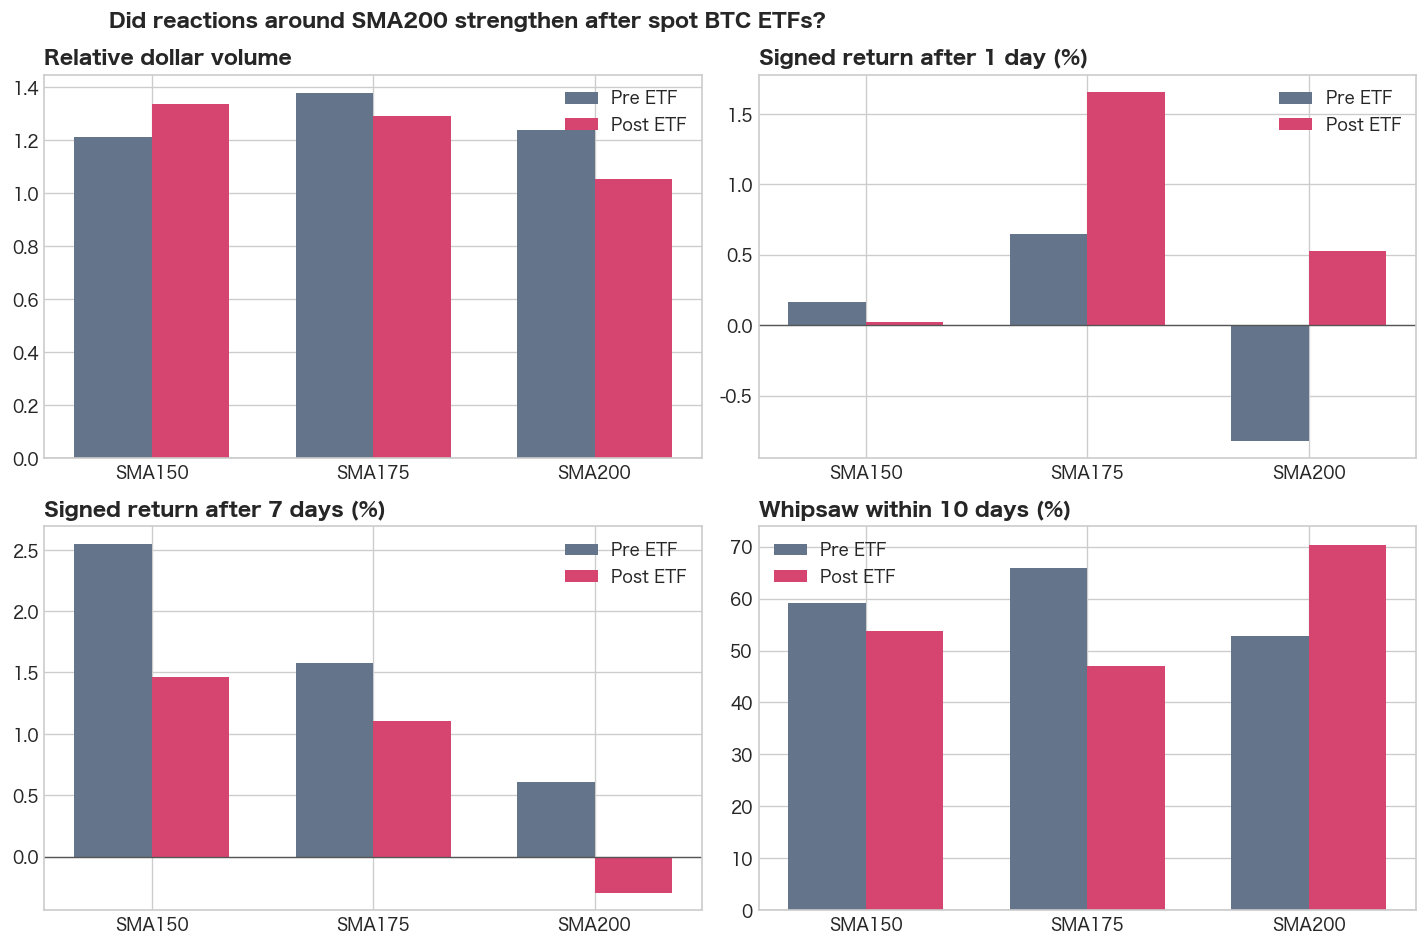

,window,delta_relative_volume_ratio,delta_signed_return_1d_pct,delta_signed_return_7d_pct,delta_whipsaw_10d_pct
0,150,0.12,-0.14,-1.08,-5.24
1,160,-0.23,-1.11,-1.24,-9.90
2,175,-0.09,1.01,-0.47,-18.90
3,190,-0.50,0.74,-1.08,7.14
4,200,-0.19,1.35,-0.91,17.59
5,225,-0.36,1.13,-0.70,7.24


In [12]:
plot_metrics = [
    ("relative_volume", "Relative dollar volume", 1.0),
    ("signed_return_1d", "Signed return after 1 day (%)", 100.0),
    ("signed_return_7d", "Signed return after 7 days (%)", 100.0),
    ("whipsaw_10d", "Whipsaw within 10 days (%)", 100.0),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
x = np.arange(len(MAIN_WINDOWS))
width = 0.35
for ax, (metric, title, scale) in zip(axes.flat, plot_metrics):
    pivot = main_summary[main_summary["period"].isin(["Pre ETF", "Post ETF"])].pivot(
        index="window", columns="period", values=metric
    ).loc[MAIN_WINDOWS]
    ax.bar(x - width / 2, pivot["Pre ETF"] * scale, width, color="#64748b", label="Pre ETF")
    ax.bar(x + width / 2, pivot["Post ETF"] * scale, width, color="#d64570", label="Post ETF")
    ax.set_xticks(x, [f"SMA{window}" for window in MAIN_WINDOWS])
    ax.set_title(title, loc="left", weight="bold")
    ax.axhline(0, color="#555", lw=0.8)
    ax.legend()
fig.suptitle("Did reactions around SMA200 strengthen after spot BTC ETFs?", x=0.08, ha="left", weight="bold")
plt.tight_layout()
plt.show()

delta_rows = []
for window in ETF_WINDOWS:
    pair = event_summary[(event_summary["window"] == window) & event_summary["period"].isin(["Pre ETF", "Post ETF"])].set_index("period")
    row = {"window": window}
    for metric, _, _ in plot_metrics:
        row[f"delta_{metric}"] = pair.loc["Post ETF", metric] - pair.loc["Pre ETF", metric]
    delta_rows.append(row)
delta_table = pd.DataFrame(delta_rows)
delta_display = delta_table.copy()
for column in ["delta_signed_return_1d", "delta_signed_return_7d", "delta_whipsaw_10d"]:
    delta_display[column] *= 100
delta_display = delta_display.rename(columns={
    "delta_relative_volume": "delta_relative_volume_ratio",
    "delta_signed_return_1d": "delta_signed_return_1d_pct",
    "delta_signed_return_7d": "delta_signed_return_7d_pct",
    "delta_whipsaw_10d": "delta_whipsaw_10d_pct",
})
display(delta_display.round(2))

## 14. 統計的な確認

ETF前後では相場局面も異なるため、単純な平均差だけでは判断しません。

```text
200日線の変化
−
150日線・175日線の平均的な変化
```

を「200日線固有の変化」として計算します。30日単位の移動ブロック・ブートストラップで95%信頼区間を作ります。また、ETF定着後と同じ長さの直前期間を使った比較も併記します。

In [13]:
BOOTSTRAP_METRICS = [
    "relative_volume", "signed_return_1d", "signed_return_7d",
    "signed_return_30d", "whipsaw_10d", "whipsaw_20d",
]
BOOTSTRAP_SAMPLES = 3000
BLOCK_DAYS = 30
RANDOM_SEED_ETF = 20260730

pre_mask = etf_daily.index < ETF_TRADING_START
post_mask = etf_daily.index >= ETF_STABLE_START
pre_index = np.flatnonzero(pre_mask)
post_index = np.flatnonzero(post_mask)

def circular_block_sample(length, block_days, rng):
    block_count = math.ceil(length / block_days)
    starts = rng.integers(0, length, size=block_count)
    offsets = np.arange(block_days)
    return ((starts[:, None] + offsets[None, :]) % length).reshape(-1)[:length]

def safe_nanmean(values):
    finite = values[np.isfinite(values)]
    return float(finite.mean()) if len(finite) else np.nan

def block_bootstrap_did(metric):
    rng = np.random.default_rng(RANDOM_SEED_ETF + BOOTSTRAP_METRICS.index(metric))
    arrays = {
        (window, "pre"): event_series[(window, metric)].to_numpy(dtype=float)[pre_index]
        for window in MAIN_WINDOWS
    }
    arrays.update({
        (window, "post"): event_series[(window, metric)].to_numpy(dtype=float)[post_index]
        for window in MAIN_WINDOWS
    })

    observed_delta = {
        window: safe_nanmean(arrays[(window, "post")]) - safe_nanmean(arrays[(window, "pre")])
        for window in MAIN_WINDOWS
    }
    observed_did = observed_delta[200] - np.mean([observed_delta[150], observed_delta[175]])

    samples = []
    for _ in range(BOOTSTRAP_SAMPLES):
        pre_draw = circular_block_sample(len(pre_index), BLOCK_DAYS, rng)
        post_draw = circular_block_sample(len(post_index), BLOCK_DAYS, rng)
        deltas = {}
        for window in MAIN_WINDOWS:
            pre_mean = safe_nanmean(arrays[(window, "pre")][pre_draw])
            post_mean = safe_nanmean(arrays[(window, "post")][post_draw])
            deltas[window] = post_mean - pre_mean
        value = deltas[200] - np.mean([deltas[150], deltas[175]])
        if np.isfinite(value):
            samples.append(value)
    samples = np.asarray(samples)
    return {
        "metric": metric,
        "did_200_vs_150_175": observed_did,
        "ci_low": np.quantile(samples, 0.025),
        "ci_high": np.quantile(samples, 0.975),
        "bootstrap_valid": len(samples),
    }

did_results = pd.DataFrame([block_bootstrap_did(metric) for metric in BOOTSTRAP_METRICS])
did_display = did_results.copy()
percent_metrics = [metric for metric in BOOTSTRAP_METRICS if metric != "relative_volume"]
mask = did_display["metric"].isin(percent_metrics)
did_display.loc[mask, ["did_200_vs_150_175", "ci_low", "ci_high"]] *= 100
did_display = did_display.rename(columns={
    "did_200_vs_150_175": "did_200_vs_150_175_pct_or_ratio",
    "ci_low": "ci_low_pct_or_ratio",
    "ci_high": "ci_high_pct_or_ratio",
})
display(did_display.round(3))

matched_view = matched_summary[matched_summary["window"].isin(MAIN_WINDOWS)].copy()
for column in ["signed_return_1d", "signed_return_7d", "signed_return_30d", "whipsaw_10d", "whipsaw_20d"]:
    matched_view[column] *= 100
matched_display = matched_view[[
    "window", "period", "relative_volume", "relative_volume_n",
    "signed_return_1d", "signed_return_1d_n", "signed_return_7d",
    "signed_return_30d", "whipsaw_10d", "whipsaw_20d",
]].rename(columns={
    "relative_volume": "relative_volume_ratio",
    "signed_return_1d": "signed_return_1d_pct",
    "signed_return_7d": "signed_return_7d_pct",
    "signed_return_30d": "signed_return_30d_pct",
    "whipsaw_10d": "whipsaw_10d_pct",
    "whipsaw_20d": "whipsaw_20d_pct",
})
display(matched_display.round(2))

,metric,did_200_vs_150_175_pct_or_ratio,ci_low_pct_or_ratio,ci_high_pct_or_ratio,bootstrap_valid
0,relative_volume,-0.205,-0.700,0.229,3000
1,signed_return_1d,0.914,-1.150,3.437,3000
2,signed_return_7d,-0.131,-2.964,2.995,3000
3,signed_return_30d,0.142,-5.172,5.305,3000
4,whipsaw_10d,29.664,1.515,53.061,3000
5,whipsaw_20d,9.513,-17.153,34.060,3000


,window,period,relative_volume_ratio,relative_volume_n,signed_return_1d_pct,signed_return_1d_n,signed_return_7d_pct,signed_return_30d_pct,whipsaw_10d_pct,whipsaw_20d_pct
0,150,Matched Pre,1.39,12,0.82,15,1.84,2.33,60.00,60.00
1,150,Post ETF,1.34,24,0.02,26,1.47,1.99,53.85,76.92
4,175,Matched Pre,1.05,5,0.90,9,2.64,4.33,55.56,55.56
5,175,Post ETF,1.29,19,1.65,17,1.11,3.01,47.06,64.71
8,200,Matched Pre,1.21,7,1.29,9,2.44,4.56,44.44,55.56
9,200,Post ETF,1.05,17,0.52,27,-0.29,1.43,70.37,77.78


## 15. 暫定結論

In [14]:
from IPython.display import Markdown

main_pair = main_summary[main_summary["period"].isin(["Pre ETF", "Post ETF"])].set_index(["window", "period"])

def change(window, metric, scale=1.0):
    return (
        main_pair.loc[(window, "Post ETF"), metric]
        - main_pair.loc[(window, "Pre ETF"), metric]
    ) * scale

volume_change_200 = change(200, "relative_volume")
return_1d_change_200 = change(200, "signed_return_1d", 100)
return_7d_change_200 = change(200, "signed_return_7d", 100)
whipsaw_change_200 = change(200, "whipsaw_10d", 100)
whipsaw_did = did_results.set_index("metric").loc["whipsaw_10d"]

conclusion = f"""
今回のBinance現物データによる探索では、**ETF後に200日線が出来高増加やトレンド継続という好ましい方向へ強く反応する証拠は確認できませんでした**。

- 200日線接近時の相対出来高変化: `{volume_change_200:+.2f}`
- 200日線クロス後1日リターンの変化: `{return_1d_change_200:+.2f}%`
- 200日線クロス後7日リターンの変化: `{return_7d_change_200:+.2f}%`
- 200日線の10日以内ダマシ率変化: `{whipsaw_change_200:+.2f}`ポイント

クロス翌日の方向調整リターンは改善しましたが、7日後の結果、接近時出来高、ダマシ率は同じ方向を示していません。
"""
if whipsaw_did["ci_low"] > 0:
    conclusion += f"""

特に10日以内のダマシ率は、150日・175日の平均変化と比べて`{whipsaw_did['did_200_vs_150_175'] * 100:+.2f}`ポイント悪化しました。30日ブロック・ブートストラップの95%区間は`{whipsaw_did['ci_low'] * 100:+.2f}`〜`{whipsaw_did['ci_high'] * 100:+.2f}`ポイントで、ゼロをまたぎません。

これは「200日線が意識されていない」という意味ではありません。注文や損切りが集中し、線の周辺で往復が増えた可能性もあります。ただし、このデータだけでは参加者の注目度と因果関係を分離できません。
"""
conclusion += """

したがって現段階では、

> 機関投資家の増加によって200日線の影響が強まった

という仮説は**不採用ではなく未確認**です。ETF後の期間とクロス回数が少ないため、追加データを蓄積し、ETFフローやCME建玉など直接的な機関投資家指標を組み合わせる必要があります。
"""
display(Markdown(conclusion))


今回のBinance現物データによる探索では、**ETF後に200日線が出来高増加やトレンド継続という好ましい方向へ強く反応する証拠は確認できませんでした**。

- 200日線接近時の相対出来高変化: `-0.19`
- 200日線クロス後1日リターンの変化: `+1.35%`
- 200日線クロス後7日リターンの変化: `-0.91%`
- 200日線の10日以内ダマシ率変化: `+17.59`ポイント

クロス翌日の方向調整リターンは改善しましたが、7日後の結果、接近時出来高、ダマシ率は同じ方向を示していません。


特に10日以内のダマシ率は、150日・175日の平均変化と比べて`+29.66`ポイント悪化しました。30日ブロック・ブートストラップの95%区間は`+1.52`〜`+53.06`ポイントで、ゼロをまたぎません。

これは「200日線が意識されていない」という意味ではありません。注文や損切りが集中し、線の周辺で往復が増えた可能性もあります。ただし、このデータだけでは参加者の注目度と因果関係を分離できません。


したがって現段階では、

> 機関投資家の増加によって200日線の影響が強まった

という仮説は**不採用ではなく未確認**です。ETF後の期間とクロス回数が少ないため、追加データを蓄積し、ETFフローやCME建玉など直接的な機関投資家指標を組み合わせる必要があります。


## 16. この追加検証の限界

- ETF後は約2年で、長期MAの独立したクロス回数が少ない
- ETF前後でBTCの相場サイクル、ボラティリティ、価格水準が異なる
- Binance出来高はETF取引量や機関投資家フローそのものではない
- UTC日足を使っており、米国市場の16時区切りとは一致しない
- 150・175・200日の結果を見た後に作った探索仮説である
- 複数のMA・期間・指標を比較しているため、偶然の差が出やすい

この検証は因果関係の証明ではなく、「200日線固有の変化が見えるか」を調べた最初のイベントスタディです。

## 17. 次にやること

```text
1. SMA150・175・200を仕様変更せず並行フォワード観測
2. ETF後のクロスイベントを追加蓄積
3. ETF日次フロー・CME建玉を使って機関投資家参加を直接測定
4. New York 16:00区切りでも同じイベント分析を実施
5. 2017年以降の複数サイクルでウォークフォワード検証
6. 急落を避けられない性質を前提に運用方法を設計
```

今は実運用BOTではなく、検証から次の仮説を作っている研究段階です。

<div style="break-before: page; page-break-before: always;"></div>

---
## 免責事項

* 本資料は教育・情報提供を目的としており、売買を推奨するものではありません。
* バックテスト結果は過去データに基づく試算であり、将来の成果を保証しません。
* 暗号資産は大きく価格変動する可能性があります。
* 手数料、スリッページ、税金、約定遅延、データ訂正等を完全には反映していません。
* ETF Flowデータは公開時刻・訂正・取得可能性によって実運用上の利用可否が変わります。
* 本資料の利用により生じたいかなる損害についても責任を負いません。
